In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from collections import Counter

sys.path.append('../src')
from utils import CFG
print(f"test path = {CFG.TRAIN_CSV}")

# Load dataset
df = pd.read_csv(CFG.TRAIN_CSV)

print(f"Shape       : {df.shape}")
print(f"Columns     : {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Device: cpu
Data dir exists: True
✅ utils.py loaded successfully
test path = ../shopee-product-matching\train.csv
Shape       : (34250, 5)
Columns     : ['posting_id', 'image', 'image_phash', 'title', 'label_group']

First 3 rows:


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891


In [ ]:
# Basic Statistics

print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n === DATA TYPES ===")
print(df.dtypes)

print(f"\n === KEY COUNTS ===")
print(f"Total postings        : {len(df):,}")
print(f"Unique label groups   : {df['label_group'].nunique():,}")
print(f"Unique images         : {df['image'].nunique():,}")
print(f"Unique image phashes  : {df['image_phash'].nunique():,}")

=== MISSING VALUES ===
posting_id     0
image          0
image_phash    0
title          0
label_group    0
dtype: int64

=== DATA TYPES ===
posting_id       str
image            str
image_phash      str
title            str
label_group    int64
dtype: object

=== KEY COUNTS ===
Total postings        : 34,250
Unique label groups   : 11,014
Unique images         : 32,412
Unique image phashes  : 28,735


=== LABEL GROUP STATS ===
Mean listings/group   : 3.11
Median listings/group : 2
Max listings/group    : 51
Min listings/group    : 2

Size distribution:
2     6979
3     1779
4      862
5      468
6      282
7      154
8      118
9       91
10      48
11      38
Name: count, dtype: int64


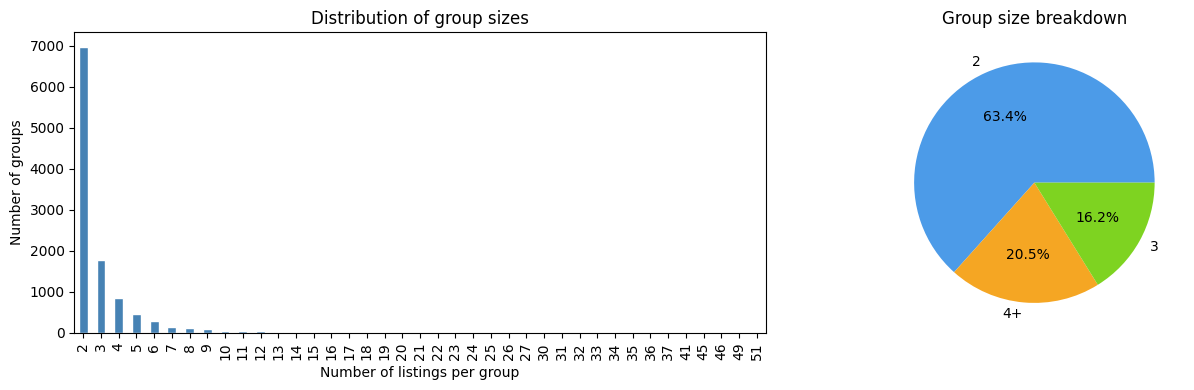


📝 Paper note: Most groups have only 2 listings — extreme sparsity.
   This makes retrieval harder than standard classification.


In [ ]:
# CLabel Group Size Distribution

group_sizes = df.groupby('label_group').size()

print("=== LABEL GROUP STATS ===")
print("in listings/group")
print(f"Mean : {group_sizes.mean():.2f}")
print(f"Median : {group_sizes.median():.0f}")
print(f"Max : {group_sizes.max()}")
print(f"Min : {group_sizes.min()}")
print(f"\nSize distribution:")
print(group_sizes.value_counts().sort_index().head(10))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full distribution
group_sizes.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribution of group sizes')
axes[0].set_xlabel('Number of listings per group')
axes[0].set_ylabel('Number of groups')

# Right: pie chart — groups with 2 vs 3 vs 4++ listings
buckets = group_sizes.apply(lambda x: '2' if x==2 else ('3' if x==3 else '4+'))
buckets.value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#4C9BE8', '#F5A623', '#7ED321']
)
axes[1].set_title('Group size breakdown')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../results/label_group_distribution.png', dpi=150)
plt.show()

print("\n Note: Most groups have only 2 listings — extreme sparsity.")
print(" This makes retrieval harder than standard classification.")

In [ ]:
# Visualize Same-Product Groups

# Pick 3 label groups that have at least 4 listings
large_groups = group_sizes[group_sizes >= 4].index[:3]

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.3)

for row_idx, group_id in enumerate(large_groups):
    group_df = df[df['label_group'] == group_id].head(4)
    for col_idx, (_, item) in enumerate(group_df.iterrows()):
        ax  = fig.add_subplot(gs[row_idx, col_idx])
        img = Image.open(
            os.path.join(CFG.TRAIN_IMG_DIR, item['image'])
        ).convert('RGB')
        ax.imshow(img)
        ax.set_title(
            f"Group {row_idx+1}\n{item['title'][:28]}...",
            fontsize=7
        )
        ax.axis('off')

fig.suptitle(
    'Same label group = same product (notice visual variation!)',
    fontsize=13, y=1.01
)
plt.savefig('../results/product_group_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("Screenshot this for your paper introduction!")
print("It visually proves why this problem is hard.")

In [ ]:
# Title Language Analysis

# Rough language detection using Indonesia languange stopwords
ID_STOPWORDS = {
    'dan', 'yang', 'untuk', 'dengan', 'ini', 'dari',
    'ke', 'di', 'atau', 'adalah', 'pada', 'jual',
    'beli', 'harga', 'murah', 'gratis', 'baru', 'toko'
}

def detect_lang(text):
    words = set(str(text).lower().split())
    return 'Bahasa Indonesia' if words & ID_STOPWORDS else 'English / Mixed'

df['lang'] = df['title'].apply(detect_lang)

print("=== LANGUAGE DISTRIBUTION ===")
print(df['lang'].value_counts())
print(f"\nPercentage Indonesian: {(df['lang']=='Bahasa Indonesia').mean()*100:.1f}%")

# Plot
df['lang'].value_counts().plot(
    kind='bar', figsize=(7, 4),
    color=['#4C9BE8', '#F5A623'], edgecolor='white'
)
plt.title('Title language distribution')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/language_distribution.png', dpi=150)
plt.show()

print("\n Note: Multilingual titles justify using XLM-R over English-only BERT.")

print("\n Sample Bahasa Indonesia titles:")
for t in df[df['lang']=='Bahasa Indonesia']['title'].head(5):
    print(f"  → {t}")

In [ ]:
# Title Length Analysis

df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))
df['title_char_count'] = df['title'].apply(lambda x: len(str(x)))

print("=== TITLE LENGTH STATS ===")
print(f"Avg word count : {df['title_word_count'].mean():.1f}")
print(f"Max word count : {df['title_word_count'].max()}")
print(f"Min word count : {df['title_word_count'].min()}")
print(f"Avg char count : {df['title_char_count'].mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['title_word_count'].hist(
    bins=40, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Word count per title')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Count')

df['title_char_count'].hist(
    bins=40, ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Character count per title')
axes[1].set_xlabel('Number of characters')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../results/title_length_distribution.png', dpi=150)
plt.show()

print("\n Note: Average title ~10 words — short enough for BERT's 512 token limit.")

In [ ]:
# Image Size Analysis

# Sample 300 images — checking all 34k takes too long locally
sample_df = df.sample(300, random_state=42)
widths, heights = [], []

for _, row in sample_df.iterrows():
    try:
        img = Image.open(
            os.path.join(CFG.TRAIN_IMG_DIR, row['image'])
        )
        widths.append(img.size[0])
        heights.append(img.size[1])
    except Exception as e:
        pass

print("=== IMAGE SIZE STATS (sample of 300) ===")
print(f"Avg size : {np.mean(widths):.0f} x {np.mean(heights):.0f} px")
print(f"Min size : {min(widths)} x {min(heights)} px")
print(f"Max size : {max(widths)} x {max(heights)} px")

# Scatter plot of width vs height
plt.figure(figsize=(7, 5))
plt.scatter(widths, heights, alpha=0.3, color='steelblue', s=10)
plt.axhline(512, color='red', linestyle='--', label='512px resize target')
plt.axvline(512, color='red', linestyle='--')
plt.title('Image width vs height (sample 300)')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/image_size_scatter.png', dpi=150)
plt.show()

print("\n Note: High size variance confirms resizing to 512×512 is necessary.")

In [ ]:
# Class Imbalance Check

top_groups    = group_sizes.nlargest(10)
bottom_groups = group_sizes.nsmallest(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_groups.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 largest product groups')
axes[0].set_xlabel('Number of listings')

bottom_groups.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Bottom 10 smallest product groups')
axes[1].set_xlabel('Number of listings')

plt.tight_layout()
plt.savefig('../results/class_imbalance.png', dpi=150)
plt.show()

print(f" Largest group has {top_groups.max()} listings,")
print(f" while {(group_sizes==1).sum()} groups have only 1 listing.")
print(f" This directly motivates ArcFace over standard cross-entropy.")

In [ ]:
# Full Dataset Summary for Paper

os.makedirs('../results', exist_ok=True)

summary = {
    'Total postings'           : len(df),
    'Unique label groups'      : df['label_group'].nunique(),
    'Avg listings per group'   : round(group_sizes.mean(), 2),
    'Max listings in one group': group_sizes.max(),
    'Groups with 2 listings'   : int((group_sizes == 2).sum()),
    'Avg title word count'     : round(df['title_word_count'].mean(), 1),
    'Indonesian titles (%)'    : f"{(df['lang']=='Bahasa Indonesia').mean()*100:.1f}%",
    'Total training images'    : len(os.listdir(CFG.TRAIN_IMG_DIR)),
}

print("=" * 50)
print("  DATASET SUMMARY — copy into your paper")
print("=" * 50)
for k, v in summary.items():
    print(f"  {k:<35}: {v}")

# Save as CSV for paper reference
pd.DataFrame(
    list(summary.items()), columns=['Metric', 'Value']
).to_csv('../results/dataset_summary.csv', index=False)

print("\n Saved to results/dataset_summary.csv")
